In [4]:
import ccxt
from dotenv import load_dotenv
import os
import pandas as pd

load_dotenv()

api_key = os.getenv('COINEX_API_KEY')
api_secret = os.getenv('COINEX_API_SECRET')

exchange = ccxt.coinex({'apiKey': api_key, 'secret': api_secret, 'enableRateLimit': True})
df = pd.DataFrame(exchange.fetch_ohlcv('ATR/USDT', '1h', limit=300))
df.columns = ['timestamp', 'open', 'high', 'low', 'close', 'volume']
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
excel_file = 'ATR_USDT_1d.csv'
df.to_csv(excel_file, index=False)




Mean Squared Error: 1.2668972177734005e-07


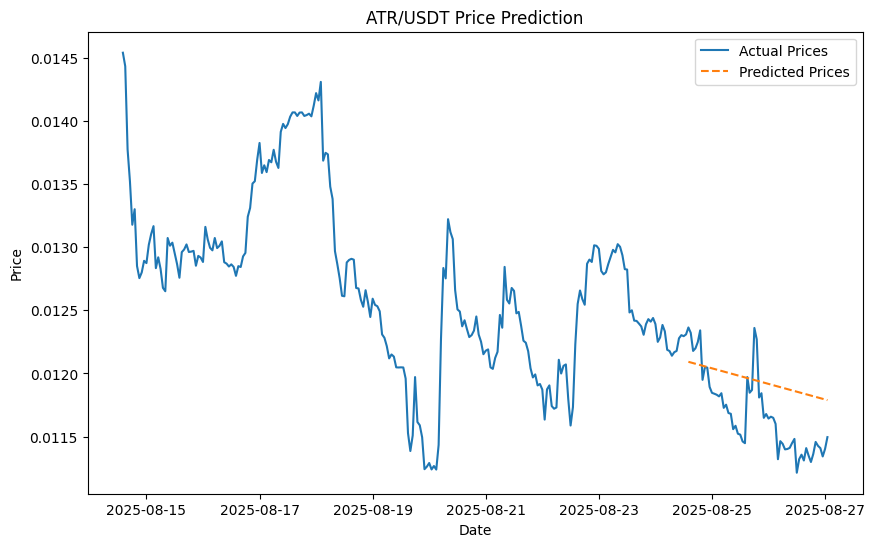

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
df["day"] = np.arange(len(df))
X = df[["day"]].values.reshape(-1, 1)
y = df["close"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
print(f"Mean Squared Error: {mse}")
plt.figure(figsize=(10, 6))
plt.plot(df['timestamp'], df['close'], label='Actual Prices')
plt.plot(df['timestamp'].iloc[len(X_train):], predictions, label='Predicted Prices', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('ATR/USDT Price Prediction')
plt.legend()
plt.show()



In [5]:
# check corrolation between ATR and BTCUSDT
df_btc = pd.DataFrame(exchange.fetch_ohlcv('BTC/USDT', '1d', limit=30))
df_btc.columns = ['timestamp', 'open', 'high', 'low', 'close', 'volume']
df_btc['timestamp'] = pd.to_datetime(df_btc['timestamp'], unit='ms')
merged_df = pd.merge(df, df_btc, on='timestamp', suffixes=('_ATR', '_BTC'))
correlation = merged_df['close_ATR'].corr(merged_df['close_BTC'])
print(f'Correlation between ATR/USDT and BTC/USDT closing prices: {correlation}')


Correlation between ATR/USDT and BTC/USDT closing prices: 0.7142104590594663


In [7]:
# check correlation between volume and price change
df_btc['price_change'] = df_btc['close'].pct_change()
correlation_volume_price = df_btc['volume'].corr(df_btc['price_change'])
print(f'Correlation between volume and price change: {correlation_volume_price}')

Correlation between volume and price change: -0.03314477280458609


In [9]:
# check rsi of ATR
def compute_rsi(data, window=14):
    delta = data['close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi
df['rsi'] = compute_rsi(df)
print(df[['timestamp', 'close', 'rsi']])

    timestamp     close        rsi
0  2025-07-28  0.012469        NaN
1  2025-07-29  0.012216        NaN
2  2025-07-30  0.011879        NaN
3  2025-07-31  0.012172        NaN
4  2025-08-01  0.011632        NaN
5  2025-08-02  0.012353        NaN
6  2025-08-03  0.013290        NaN
7  2025-08-04  0.013274        NaN
8  2025-08-05  0.012822        NaN
9  2025-08-06  0.014306        NaN
10 2025-08-07  0.013708        NaN
11 2025-08-08  0.013752        NaN
12 2025-08-09  0.013596        NaN
13 2025-08-10  0.013853  61.366623
14 2025-08-11  0.013307  56.315948
15 2025-08-12  0.014098  63.120468
16 2025-08-13  0.015170  70.810674
17 2025-08-14  0.012892  53.639304
18 2025-08-15  0.012918  56.856473
19 2025-08-16  0.013693  57.103478
20 2025-08-17  0.014122  54.661587
21 2025-08-18  0.012447  46.092790
22 2025-08-19  0.011261  43.103296
23 2025-08-20  0.012152  39.957106
24 2025-08-21  0.011916  41.353021
25 2025-08-22  0.013011  46.753702
26 2025-08-23  0.012439  45.109477
27 2025-08-24  0.011

In [11]:
# check rsi of btc
df_btc['rsi'] = compute_rsi(df_btc)
print(df_btc[['timestamp', 'close', 'rsi']])


    timestamp      close        rsi
0  2025-07-28  118025.16        NaN
1  2025-07-29  117904.36        NaN
2  2025-07-30  117824.55        NaN
3  2025-07-31  115769.71        NaN
4  2025-08-01  113327.16        NaN
5  2025-08-02  112564.35        NaN
6  2025-08-03  114189.49        NaN
7  2025-08-04  115081.15        NaN
8  2025-08-05  114136.89        NaN
9  2025-08-06  114987.84        NaN
10 2025-08-07  117425.73        NaN
11 2025-08-08  116659.01        NaN
12 2025-08-09  116472.72        NaN
13 2025-08-10  119254.00  53.853371
14 2025-08-11  118698.77  52.041214
15 2025-08-12  120118.00  56.218558
16 2025-08-13  123283.00  63.068591
17 2025-08-14  118299.00  55.310731
18 2025-08-15  117298.00  58.874790
19 2025-08-16  117398.00  61.133005
20 2025-08-17  117383.00  57.944644
21 2025-08-18  116199.00  52.741058
22 2025-08-19  112888.00  47.256102
23 2025-08-20  114267.00  48.452179
24 2025-08-21  112451.00  39.024919
25 2025-08-22  116895.00  50.447951
26 2025-08-23  115407.00  48

## find trends cryptocurrency

In [12]:
import requests
import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

def get_coingecko_trending():
    """گرفتن ارزهای trending از CoinGecko"""
    try:
        response = requests.get("https://api.coingecko.com/api/v3/search/trending")
        data = response.json()
        trending_coins = [coin['item']['id'] for coin in data['coins']]
        logger.info(f"ارزهای trending از CoinGecko: {trending_coins}")
        return trending_coins
    except Exception as e:
      logger.error(f"خطا در گرفتن trending از CoinGecko: {e}")
      return []

# در main، بعد از تحلیل:
trending = get_coingecko_trending()

INFO:__main__:ارزهای trending از CoinGecko: ['notcoin', 'ethereum', 'hyperliquid', 'pinlink', 'chainlink', 'aave', 'solana', 'ripple', 'pepe', 'sui', 'polkadot', 'pi-network', 'stader', 'ethena', 'bitcoin']
